# Module 6 — Personality Compliance

**Research Question**: How well do LLMs follow personality instructions (cooperative vs selfish) across languages?

**Key Analysis**: Measure personality compliance as the gap between cooperative and selfish agent behavior, and how this varies by model and language.

**Outputs**: Figure 6a (personality gap heatmap), Figure 6b (compliance ranking), Figure 6c (personality × noise interaction)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
LANG_LABELS = {
    'en': 'English', 'fr': 'French', 'ar': 'Arabic',
    'cn': 'Chinese', 'vn': 'Vietnamese', 'it': 'Italian'
}
PERSONALITY_MAP = {
    'cooperative': 'Cooperative', 'selfish': 'Selfish',
    'coopératif': 'Cooperative', 'égoïste': 'Selfish',
    'متعاون': 'Cooperative', 'أناني': 'Selfish',
    '合作型的': 'Cooperative', '自私型的': 'Selfish',
    'một người hợp tác': 'Cooperative', 'một người ích kỷ': 'Selfish',
    'cooperativo': 'Cooperative', 'egoista': 'Selfish'
}
FIGURE_DIR = 'figures/'
import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
DATA_PATH = '../resources/results/Prisoner_dilemma_2player/consolidated_dataset.csv'
df = pd.read_csv(DATA_PATH)
df['personality'] = df['agent1_personality'].map(PERSONALITY_MAP)
df['model'] = df['agent1_llm'].map(MODEL_LABELS)
df['lang_full'] = df['language'].map(LANG_LABELS)
print(f'Loaded {len(df)} games.')

Loaded 2160 games.


## 6.1 Personality Compliance Metrics

In [3]:
# ── Compute Cohen's d for each Model × Language combination ──
models_order = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
lang_order = ['English', 'French', 'Arabic', 'Chinese', 'Vietnamese', 'Italian']

effect_rows = []
for model in models_order:
    for lang in lang_order:
        coop = df[(df['model'] == model) & (df['lang_full'] == lang) & 
                  (df['personality'] == 'Cooperative')]['agent1_cooperation_rate']
        self_ = df[(df['model'] == model) & (df['lang_full'] == lang) & 
                   (df['personality'] == 'Selfish')]['agent1_cooperation_rate']
        
        if len(coop) > 0 and len(self_) > 0:
            pooled_std = np.sqrt((coop.std()**2 + self_.std()**2) / 2)
            d = (coop.mean() - self_.mean()) / pooled_std if pooled_std > 0 else 0
            gap = coop.mean() - self_.mean()
            U, p = stats.mannwhitneyu(coop, self_, alternative='two-sided')
            
            effect_rows.append({
                'Model': model, 'Language': lang,
                'Coop_Mean': coop.mean(), 'Self_Mean': self_.mean(),
                'Gap': gap, 'Cohens_d': d, 'p_value': p
            })

effects = pd.DataFrame(effect_rows)
display(effects.round(3))

,Model,Language,Coop_Mean,Self_Mean,Gap,Cohens_d,p_value
0,GPT-oss-20B,English,0.098,0.082,0.016,0.166,0.193
1,GPT-oss-20B,French,0.241,0.079,0.162,0.799,0.000
2,GPT-oss-20B,Arabic,0.135,0.084,0.051,0.513,0.001
3,GPT-oss-20B,Chinese,0.116,0.077,0.038,0.410,0.001
4,GPT-oss-20B,Vietnamese,0.090,0.083,0.007,0.067,0.251
5,GPT-oss-20B,Italian,0.280,0.086,0.194,1.285,0.000
6,Mistral-7B,English,0.840,0.084,0.756,4.661,0.000
7,Mistral-7B,French,0.891,0.094,0.797,6.278,0.000
8,Mistral-7B,Arabic,0.882,0.810,0.072,0.465,0.041
9,Mistral-7B,Chinese,0.922,0.113,0.809,7.726,0.000


## 6.2 Figure 6a — Personality Gap Heatmap (Model × Language)

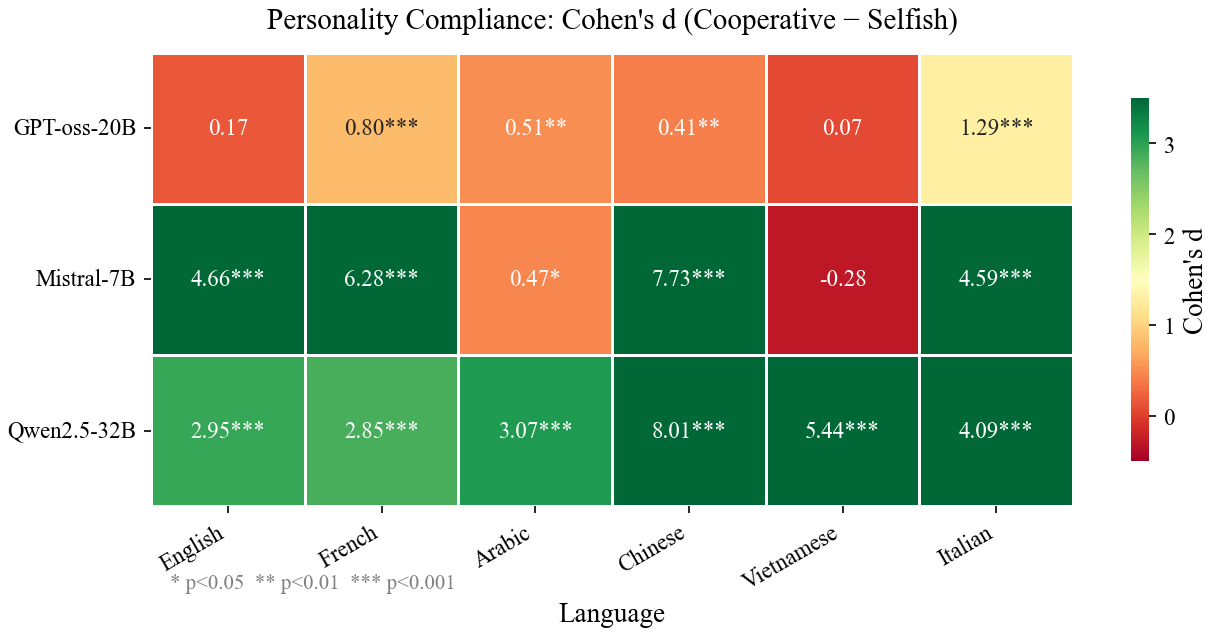

Saved: fig6a_personality_compliance_heatmap.pdf/png


In [4]:
# ── Figure 6a: Cohen's d heatmap ──
d_pivot = effects.pivot_table(values='Cohens_d', index='Model', columns='Language')
d_pivot = d_pivot.reindex(models_order)[lang_order]

p_pivot = effects.pivot_table(values='p_value', index='Model', columns='Language')
p_pivot = p_pivot.reindex(models_order)[lang_order]

# Create annotation with significance stars
annot = d_pivot.copy().astype(str)
for model in models_order:
    for lang in lang_order:
        d_val = d_pivot.loc[model, lang]
        p_val = p_pivot.loc[model, lang]
        stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
        annot.loc[model, lang] = f'{d_val:.2f}{stars}'

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(
    d_pivot, annot=annot, fmt='', cmap='RdYlGn',
    vmin=-0.5, vmax=3.5, linewidths=0.5, linecolor='white',
    cbar_kws={'label': "Cohen's d", 'shrink': 0.8},
    annot_kws={'fontsize': 11}, ax=ax
)
ax.set_title("Personality Compliance: Cohen's d (Cooperative − Selfish)", fontsize=14, pad=12)
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# Legend for significance
ax.text(0.02, -0.18, '* p<0.05  ** p<0.01  *** p<0.001',
        transform=ax.transAxes, fontsize=10, color='gray')

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig6a_personality_compliance_heatmap.pdf')
fig.savefig(f'{FIGURE_DIR}fig6a_personality_compliance_heatmap.png')
plt.show()
print('Saved: fig6a_personality_compliance_heatmap.pdf/png')

## 6.3 Figure 6b — Compliance Ranking: Which Model Follows Instructions Best?

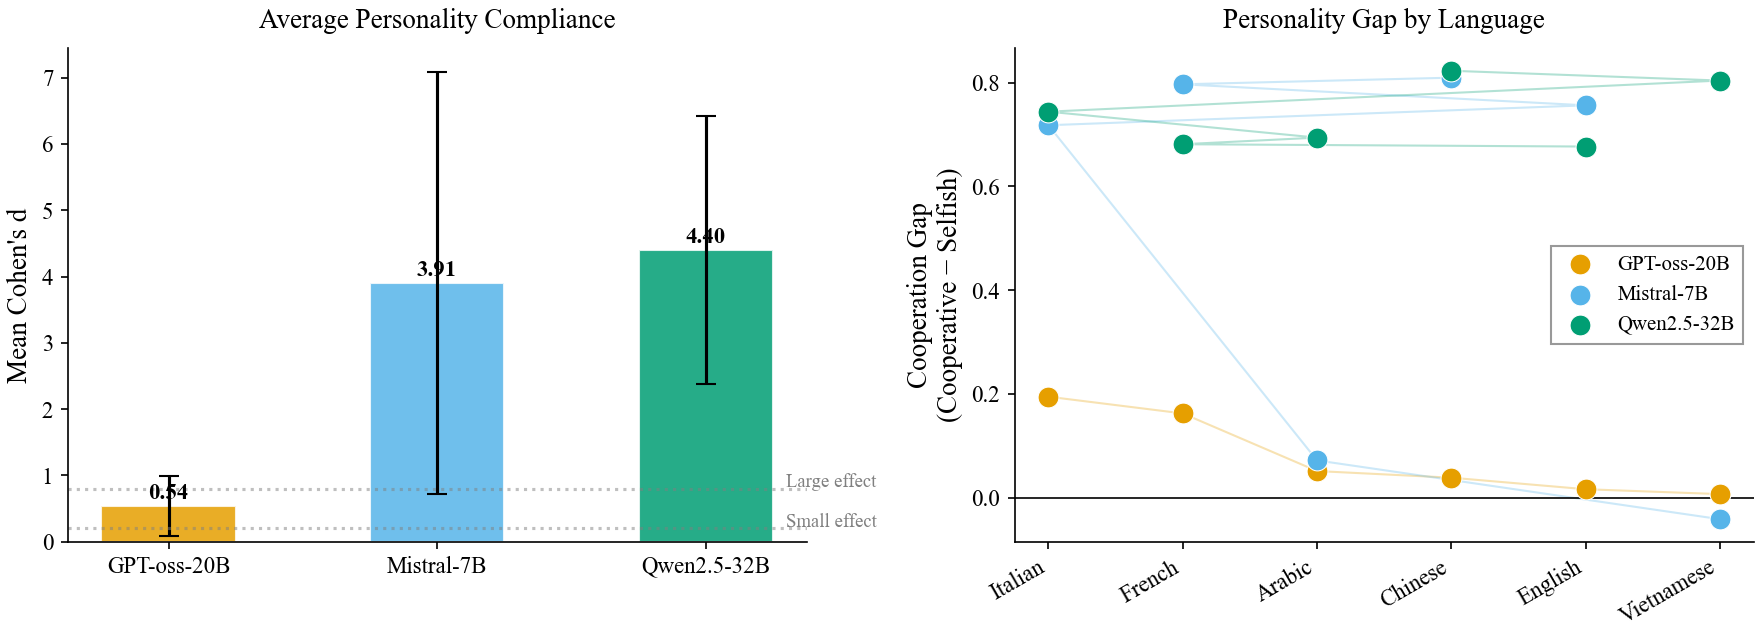

Saved: fig6b_compliance_ranking.pdf/png


In [5]:
# ── Figure 6b: Average Cohen's d per model (aggregated across languages) ──
model_compliance = effects.groupby('Model').agg(
    mean_d=('Cohens_d', 'mean'),
    std_d=('Cohens_d', 'std'),
    mean_gap=('Gap', 'mean'),
    min_d=('Cohens_d', 'min'),
    max_d=('Cohens_d', 'max')
).reindex(models_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: bar chart of mean Cohen's d
MODEL_COLORS = {'GPT-oss-20B': '#E69F00', 'Mistral-7B': '#56B4E9', 'Qwen2.5-32B': '#009E73'}
ax = axes[0]
colors = [MODEL_COLORS[m] for m in models_order]
bars = ax.bar(models_order, model_compliance['mean_d'], 
              yerr=model_compliance['std_d'], capsize=5,
              color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, model_compliance['mean_d']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel("Mean Cohen's d")
ax.set_title('Average Personality Compliance', fontsize=13, pad=10)
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.5)
ax.text(2.3, 0.82, 'Large effect', fontsize=9, color='gray')
ax.axhline(y=0.2, color='gray', linestyle=':', alpha=0.5)
ax.text(2.3, 0.22, 'Small effect', fontsize=9, color='gray')

# Right: personality gap per language per model (dot plot)
ax = axes[1]
for model in models_order:
    sub = effects[effects['Model'] == model].sort_values('Gap', ascending=False)
    ax.scatter(sub['Language'], sub['Gap'], s=100, color=MODEL_COLORS[model],
               label=model, zorder=5, edgecolor='white', linewidth=0.5)
    ax.plot(sub['Language'], sub['Gap'], color=MODEL_COLORS[model],
            alpha=0.3, linewidth=1)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Cooperation Gap\n(Cooperative − Selfish)')
ax.set_title('Personality Gap by Language', fontsize=13, pad=10)
ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig6b_compliance_ranking.pdf')
fig.savefig(f'{FIGURE_DIR}fig6b_compliance_ranking.png')
plt.show()
print('Saved: fig6b_compliance_ranking.pdf/png')

## 6.4 Figure 6c — Personality × Noise Interaction

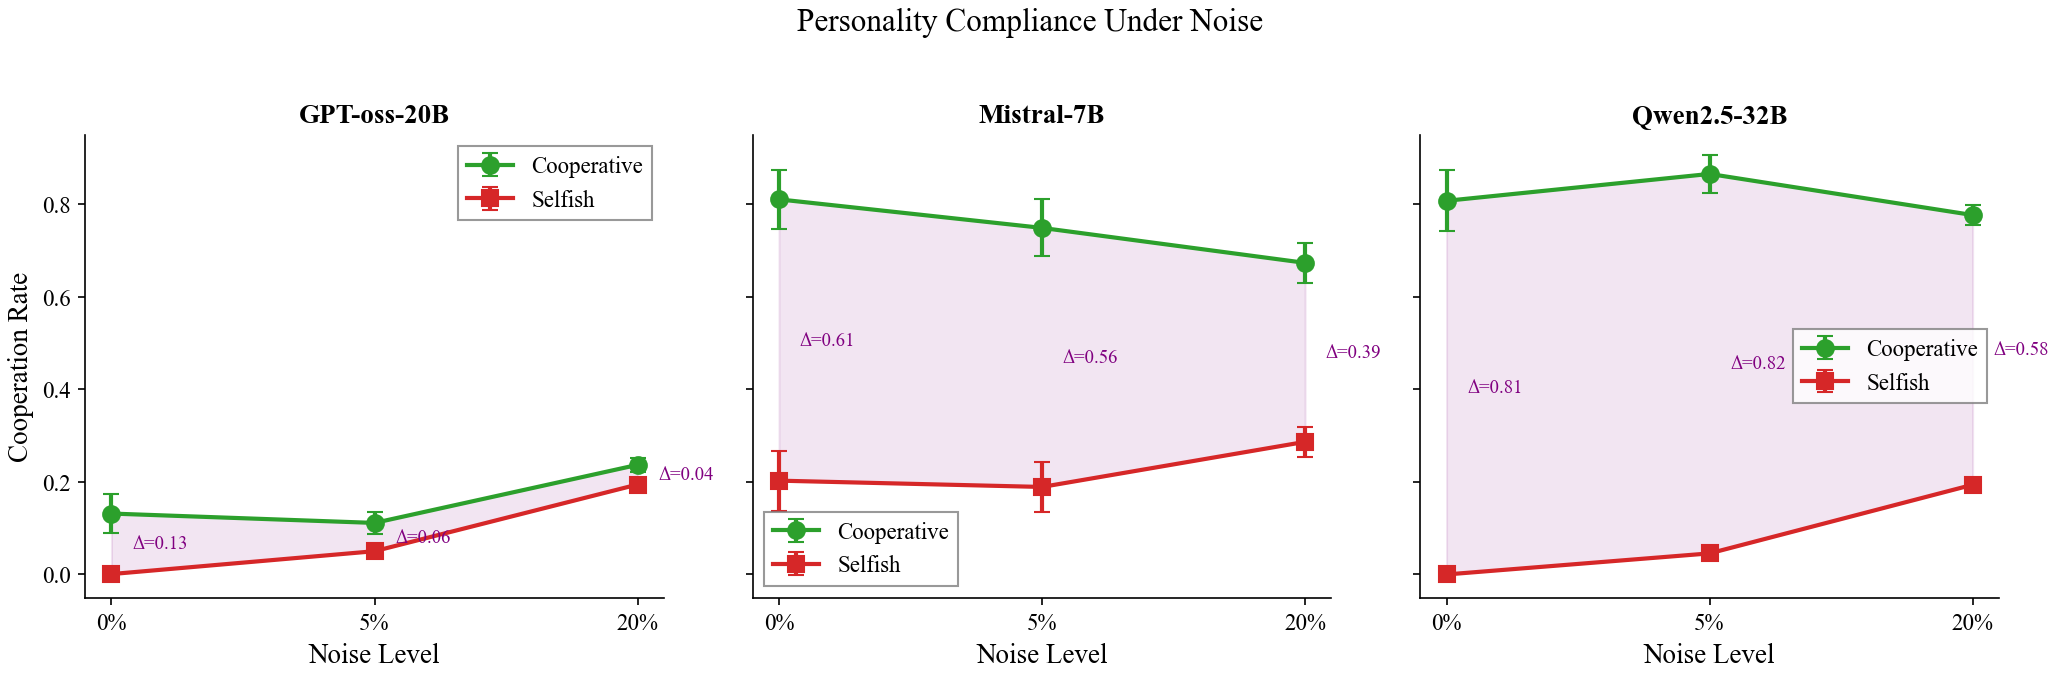

Saved: fig6c_personality_noise_interaction.pdf/png


In [6]:
# ── Figure 6c: Does noise weaken or strengthen personality compliance? ──
noise_levels = [0.0, 0.05, 0.2]
NOISE_LABELS = {0.0: '0%', 0.05: '5%', 0.2: '20%'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for idx, model in enumerate(models_order):
    ax = axes[idx]
    sub = df[df['model'] == model]
    
    for pers, color, marker in [('Cooperative', '#2ca02c', 'o'), ('Selfish', '#d62728', 's')]:
        ps = sub[sub['personality'] == pers]
        means = [ps[ps['agent1_noise_rate'] == n]['agent1_cooperation_rate'].mean() for n in noise_levels]
        sems = [ps[ps['agent1_noise_rate'] == n]['agent1_cooperation_rate'].sem() for n in noise_levels]
        
        ax.errorbar([NOISE_LABELS[n] for n in noise_levels], means,
                    yerr=np.array(sems) * 1.96,
                    marker=marker, markersize=8, linewidth=2, capsize=4,
                    color=color, label=pers)
    
    # Shade personality gap
    coop_means = [sub[(sub['personality'] == 'Cooperative') & 
                      (sub['agent1_noise_rate'] == n)]['agent1_cooperation_rate'].mean() for n in noise_levels]
    self_means = [sub[(sub['personality'] == 'Selfish') & 
                      (sub['agent1_noise_rate'] == n)]['agent1_cooperation_rate'].mean() for n in noise_levels]
    xl = [NOISE_LABELS[n] for n in noise_levels]
    ax.fill_between(xl, coop_means, self_means, alpha=0.1, color='purple')
    
    # Annotate gap
    for i, n in enumerate(noise_levels):
        gap = coop_means[i] - self_means[i]
        mid = (coop_means[i] + self_means[i]) / 2
        ax.annotate(f'Δ={gap:.2f}', (xl[i], mid), fontsize=9,
                    ha='left', va='center', xytext=(10, 0),
                    textcoords='offset points', color='purple')
    
    ax.set_xlabel('Noise Level')
    ax.set_title(model, fontsize=13, fontweight='bold')
    ax.set_ylim(-0.05, 0.95)
    ax.legend(loc='best', frameon=True, fancybox=False, edgecolor='gray')

axes[0].set_ylabel('Cooperation Rate')
fig.suptitle('Personality Compliance Under Noise', fontsize=15, y=1.02)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig6c_personality_noise_interaction.pdf')
fig.savefig(f'{FIGURE_DIR}fig6c_personality_noise_interaction.png')
plt.show()
print('Saved: fig6c_personality_noise_interaction.pdf/png')

## 6.5 Statistical Tests

In [7]:
# ── Two-way interaction: Personality × Noise per model ──
print('=== Personality × Noise Interaction Tests ===')
print('-' * 65)

for model in models_order:
    sub = df[df['model'] == model]
    
    # Compute personality gap at each noise level
    gaps = []
    for noise in noise_levels:
        coop = sub[(sub['personality'] == 'Cooperative') & 
                   (sub['agent1_noise_rate'] == noise)]['agent1_cooperation_rate']
        self_ = sub[(sub['personality'] == 'Selfish') & 
                    (sub['agent1_noise_rate'] == noise)]['agent1_cooperation_rate']
        gap = coop.mean() - self_.mean()
        pooled_std = np.sqrt((coop.std()**2 + self_.std()**2) / 2)
        d = gap / pooled_std if pooled_std > 0 else 0
        gaps.append({'noise': NOISE_LABELS[noise], 'gap': gap, 'd': d})
    
    print(f'\n{model}:')
    for g in gaps:
        print(f"  Noise={g['noise']}: Gap={g['gap']:.3f}, Cohen's d={g['d']:.3f}")
    
    # Does the gap change significantly across noise?
    # Compare gap at 0% vs 20% using bootstrap
    coop_0 = sub[(sub['personality'] == 'Cooperative') & (sub['agent1_noise_rate'] == 0.0)]['agent1_cooperation_rate'].values
    self_0 = sub[(sub['personality'] == 'Selfish') & (sub['agent1_noise_rate'] == 0.0)]['agent1_cooperation_rate'].values
    coop_20 = sub[(sub['personality'] == 'Cooperative') & (sub['agent1_noise_rate'] == 0.2)]['agent1_cooperation_rate'].values
    self_20 = sub[(sub['personality'] == 'Selfish') & (sub['agent1_noise_rate'] == 0.2)]['agent1_cooperation_rate'].values
    
    gap_0 = coop_0.mean() - self_0.mean()
    gap_20 = coop_20.mean() - self_20.mean()
    print(f'  Gap change (0%→20%): {gap_20 - gap_0:+.3f}')
    print(f'  Interpretation: Noise {"weakens" if gap_20 < gap_0 else "strengthens"} personality compliance')

=== Personality × Noise Interaction Tests ===
-----------------------------------------------------------------

GPT-oss-20B:
  Noise=0%: Gap=0.131, Cohen's d=0.784
  Noise=5%: Gap=0.061, Cohen's d=0.627
  Noise=20%: Gap=0.043, Cohen's d=0.523
  Gap change (0%→20%): -0.088
  Interpretation: Noise weakens personality compliance

Mistral-7B:
  Noise=0%: Gap=0.608, Cohen's d=1.695
  Noise=5%: Gap=0.560, Cohen's d=1.721
  Noise=20%: Gap=0.387, Cohen's d=1.810
  Gap change (0%→20%): -0.221
  Interpretation: Noise weakens personality compliance

Qwen2.5-32B:
  Noise=0%: Gap=0.808, Cohen's d=3.084
  Noise=5%: Gap=0.820, Cohen's d=4.933
  Noise=20%: Gap=0.583, Cohen's d=6.121
  Gap change (0%→20%): -0.225
  Interpretation: Noise weakens personality compliance
